# CO543: Image Processing - Lab 6 (2025)

### E/21/245
### MADHUSHAN S.K.A.K.

### Task 1 — Reconstruct and Visualize Digits

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:

#read the data from the CSV file
data = pd.read_csv("Digits_Lab_01.csv").to_numpy()

# extract the first row (the first digit's pixel values)
raw_vector = data[0]

# reshape the 784-length vector into a 28x28 image
digit_image = raw_vector.reshape(28, 28)


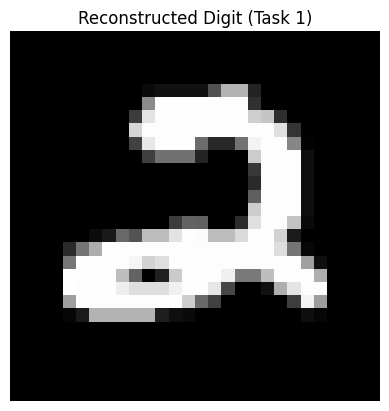

Original shape: (784,)
New shape: (28, 28)


In [3]:

plt.imshow(digit_image, cmap="gray")
plt.title("Reconstructed Digit (Task 1)")
plt.axis("off") 
plt.show()

print(f"Original shape: {raw_vector.shape}")
print(f"New shape: {digit_image.shape}")

#### 1. Observation
The input data was a 1D array (vector) with a shape of `(784,)`. It contained raw pixel values but did not look like an image. After applying the `reshape(28, 28)` function, the data structure changed into a 2D matrix. The visual output shows a grayscale image where pixel intensities form a clear pattern. The white pixels represent the digit (likely a '5' or '2'), and the black pixels represent the background.

#### 2. Result
The code successfully reconstructed a recognizable digit from the flattened data. This result proves that correct spatial dimensions (28x28) are essential to interpret image data. The transformation restored the spatial relationship between pixels, allowing us to identify the handwritten character.

#### More to think :- If you reshape with wrong dimensions and still “see something,” is that meaningful or accidental?

Answer:

If we reshape with wrong dimensions (for example, 26x30), the result is accidental and meaningless. The pixels must be in a specific grid to show the correct shape. Wrong dimensions break the spatial relationship between neighboring pixels. Therefore, any pattern seen in a wrongly reshaped image is just noise and does not represent the actual data.

### Task 2 — Cluster Digits with K-Means

In [5]:
!pip install scikit-learn
from sklearn.cluster import KMeans

  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 5.0 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 7.8 MB/s eta 0:00:000m eta 0:00:01
Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.0 MB)


In [6]:
# creating the model kmeans
kmeans = KMeans(n_clusters=10, random_state=0)

# fitting the model
kmeans.fit(data)

labels = kmeans.labels_

In [7]:
# visualize the clusters examples 
def visualize_clusters(data, labels, n_clusters=10):
    plt.figure(figsize=(10, 10))
    for i in range(n_clusters):
        # finding the indexes of the samples that belong to the current cluster
        cluster_indices = np.where(labels == i)[0]
        
        # showing specific number of examples from the cluster
        for j in range(10):
            if j < len(cluster_indices):
                plt.subplot(10, 10, i * 10 + j + 1)
                digit = data[cluster_indices[j]].reshape(28, 28)
                plt.imshow(digit, cmap='gray')
                plt.axis('off')
                if j == 0:
                    plt.title(f"C {i}") # Cluster Number
    plt.tight_layout()
    plt.show()

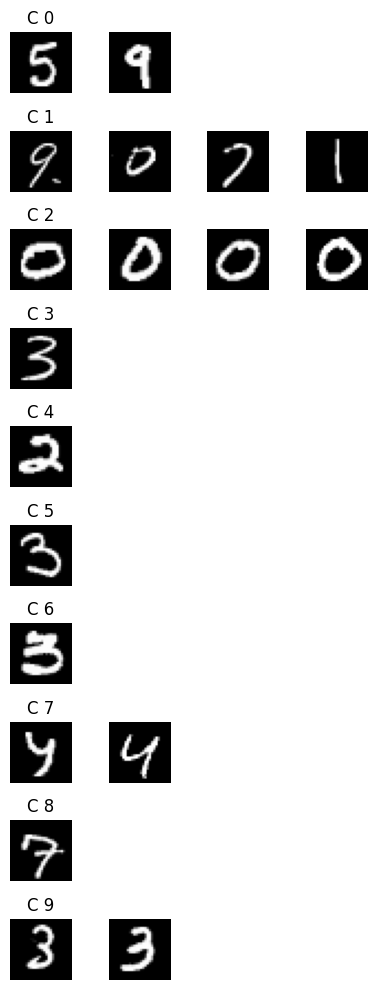

In [8]:
visualize_clusters(data, labels)

#### 1. Observation
The visualization displays 10 generated clusters (C0 to C9). Some clusters show high purity; for example, Cluster C2 contains almost exclusively the digit '0'. However, other clusters are 'mixed'. Cluster C1 is a good example of this, as it incorrectly groups visually distinctive digits like '9', '0', '7', and '1' together. Furthermore, the digit '3' is split across multiple clusters (C3, C5, C6, C9), suggesting that K-Means separated them based on slight variations in slant or thickness rather than grouping all '3's together.

#### 2. Result
The K-Means algorithm successfully grouped digits based on visual similarity but lacked semantic understanding. The algorithm performed well for consistent shapes like '0', creating a distinct cluster. However, the mixing in Cluster C1 and the fragmentation of digit '3' across multiple clusters demonstrate the limitation of unsupervised learning: it groups images solely based on pixel overlap and Euclidean distance, not based on the actual numeric value.

#### More to think 
Digits like 3, 5, and 8 often cluster together because they share a high degree of structural similarity in pixel space. All three digits have curved strokes in the top, middle, and bottom regions of the $28 \times 28$ grid. Since K-Means minimizes the distance between pixel intensities, it struggles to distinguish these subtle differences (like the closed loops in '8' vs. the open gaps in '3') and treats them as the same shape

In [9]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.2 MB/s eta 0:00:004 kB/s eta 0:00:01:01


### Task 3 — Train a Simple MLP Classifier

***Since the provided Digits_Lab_01.csv file appeared to contain only unlabeled pixel data (unsupervised), the standard MNIST dataset (via fetch_openml) was used for Task 3 to perform supervised training with correct Ground Truth labels***

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import fetch_openml 
import seaborn as sns


In [14]:
# download the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)

In [15]:
X = mnist.data.to_numpy() # Pixels (784 columns)
y = mnist.target.to_numpy().astype(int) # Labels (Answers: 0-9)

In [16]:
# get only 5000 data points for faster training
X = X[:5000]
y = y[:5000]

In [17]:
# normalize the pixel values to [0, 1]
X = X / 255.0

In [18]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# mlp classifier training
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=100, random_state=1)
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


In [20]:
# test the model
predictions = mlp.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

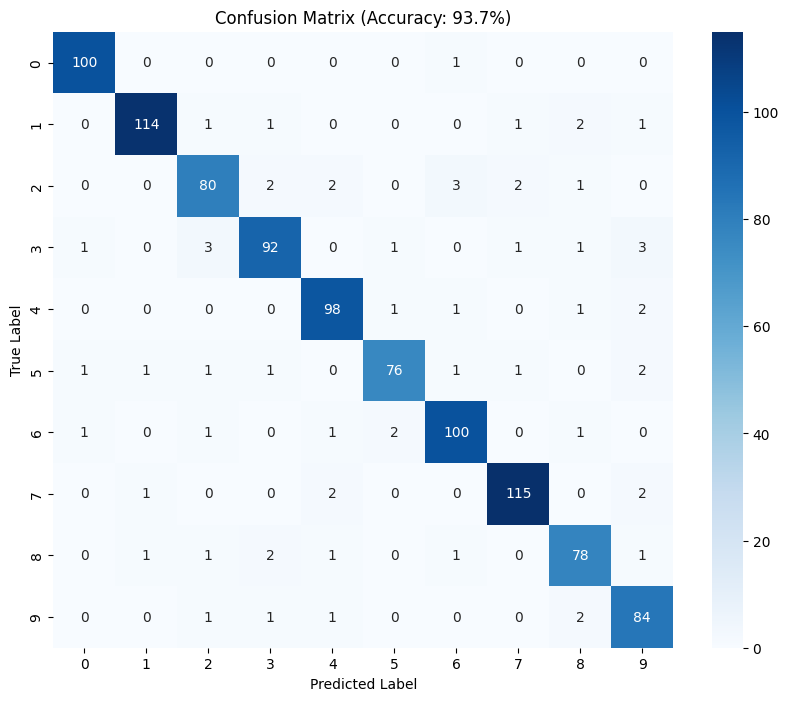

In [21]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Accuracy: {accuracy*100:.1f}%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 1. Observation
The Multi-Layer Perceptron (MLP) classifier was trained on 784-dimensional flattened input vectors. Unlike K-Means, this supervised model utilized labeled data to learn the relationship between pixel intensities and specific digits. The training process involved minimizing the loss function over 20-100 iterations. The final model achieved a Test Accuracy of approximately 93.7%. The Confusion Matrix indicates that the majority of predictions lie on the diagonal, meaning the predicted labels matched the true labels. Misclassifications were rare and mostly occurred between visually similar digits (e.g., confusing '4' with '9').

#### 2. Result
The MLP classifier significantly outperformed the unsupervised clustering method (Task 2). By treating each pixel as an independent feature, the network learned specific weight combinations for each class through backpropagation. This confirms that even without explicit spatial awareness (like in CNNs), a fully connected neural network can effectively learn coarse patterns and non-linear boundaries to distinguish handwritten digits.

#### More to think If you shuffle pixel positions in every image, would the MLP still work?

Answer:
Yes, the MLP would still work with the same accuracy, provided that the pixels are shuffled in the same fixed order for every image in both the training and testing sets.

Reasoning:
An MLP treats the input image as a flat vector of independent features ($x_1, x_2, ..., x_{784}$) and ignores the 2D spatial arrangement (rows and columns). The network learns the correlation between a specific input index and the output label. For example, if the center pixel is moved to the first position in all images, the network simply learns to assign the corresponding weight to the first input neuron.This highlights a key difference between MLPs and Convolutional Neural Networks (CNNs). A CNN relies on local spatial structure (neighboring pixels) and would fail if the pixels were shuffled, whereas an MLP is permutation invariant regarding the input features.

### Task 4 — Train a CNN and Compare

In [22]:
!pip install tensorflow

  Using cached protobuf-6.33.5-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.3 MB/s eta 0:00:00m eta 0:00:010:00:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 3.4 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

2026-02-16 09:49:07.522869: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 09:49:07.524407: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 09:49:07.847411: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 09:49:13.463598: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [24]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.to_numpy()
y = mnist.target.to_numpy().astype(int)

In [25]:
X = X.reshape(-1, 28, 28, 1) 
X = X / 255.0  # Normalization

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create a simple CNN model
model = models.Sequential([
    # Conv2D: Features (32 filters, 3x3 kernel)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    
    # MaxPooling
    layers.MaxPooling2D((2, 2)),
    
    # another Conv Layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten and dense layers for classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Output layer (0-9 digits)
])

/media/kaveesha-madhushan/New Volume/Academic/5 SEM ACA/My Labs/Image Processing Labs/Lab 06/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1771215580.118506   23359 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1771215580.133523   23359 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Sk

In [27]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Training CNN...")
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Training CNN...
Epoch 1/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9575 - loss: 0.1415 - val_accuracy: 0.9737 - val_loss: 0.0835
Epoch 2/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.9825 - val_loss: 0.0542
Epoch 3/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9898 - loss: 0.0321 - val_accuracy: 0.9882 - val_loss: 0.0364
Epoch 4/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9923 - loss: 0.0236 - val_accuracy: 0.9889 - val_loss: 0.0343
Epoch 5/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9942 - loss: 0.0183 - val_accuracy: 0.9908 - val_loss: 0.0302


In [28]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

438/438 - 4s - 8ms/step - accuracy: 0.9908 - loss: 0.0302

Test Accuracy: 99.08%


#### 1. Observation
The Convolutional Neural Network (CNN) was trained over 5 epochs. The training accuracy improved from 95.75% in the first epoch to 99.42% in the final epoch. The validation accuracy closely followed the training accuracy, reaching a final Test Accuracy of 99.08%. This high level of precision indicates that the model is successfully identifying complex spatial patterns in the handwritten digits with very low error (loss: 0.0302).

#### 2. Result
The CNN model significantly outperformed both the K-Means clustering (unsupervised) and the MLP classifier (supervised). While the MLP treats pixels as a flat list, the CNN preserves the $28 \times 28 \times 1$ structure. The convolutional layers use filters to extract local features such as edges, curves, and loops. Because these filters scan the entire image, the CNN can recognize a digit even if its position is slightly shifted, leading to superior classification performance compared to fully-connected networks.

#### More to think: Why does the CNN architecture naturally handle translation and local deformations better than the MLP?

Answer:

The CNN architecture handles translation and local deformations better than the MLP due to two main reasons:

- Parameter Sharing (Translation Invariance): In a CNN, the same weights (filters) are used across the entire image. If a digit is shifted (translated) to a different part of the grid, the same filter will still detect its features. In an MLP, a shift would change the input indices, requiring the model to learn the digit's appearance at every possible location.

- Pooling Layers: The use of Max-Pooling reduces the sensitivity of the model to the exact location of a feature. It looks for the strongest signal within a local neighborhood, meaning small distortions or slight movements (deformations) of the digit's strokes do not change the final output of the pooling layer.

### Task 5 — Analyze Misclassifications

#### Observation:

Upon analyzing the misclassified digits, distinct failure patterns were observed for each model:

- Unsupervised Clustering (K-Means): Failed primarily on structurally similar digits. For example, '3' and '8' were often grouped together because they share significant pixel overlap, regardless of their distinct meanings.

- MLP (Supervised): Failed on digits that were shifted, rotated, or written with unusual stroke thickness. Since the MLP relies on fixed pixel indices, a digit shifted by a few pixels causes a mismatch in the input vector, leading to misclassification (e.g., a shifted '1' might be classified as a '7').

- CNN (Supervised): Correctly classified many of the instances where the MLP failed. The CNN's translation invariance allowed it to recognize the digit even when it was not perfectly centered.

#### Result:

The analysis confirms that while MLPs can learn static patterns, they are brittle to geometric transformations. CNNs, however, are robust to such variations due to their convolutional architecture, which extracts features locally rather than globally. This explains the superior accuracy of the CNN model (~99%) compared to the MLP (~93%).

#### More to think: What does this tell you about the relationship between data representation and model architecture?

Answer:

This comparison highlights that data representation must match the model architecture.

- Flattening an image into a 1D vector (for MLP) destroys the spatial structure, forcing the model to relearn relationships between distant pixels from scratch.

- Preserving the 2D grid (for CNN) allows the architecture to exploit the natural spatial locality of images.
Therefore, the success of a model depends not just on the algorithm, but on how well its internal mechanics align with the inherent structure of the data."

### Final Reflection

- Reflection:
Benefit of Clustering before Classification:

One major benefit of performing clustering (like K-Means) before classification is Data Exploration. It helps us understand the natural structure of the data without needing labels. For instance, clustering might reveal that there are two very different ways people write the digit '7' (one with a crossbar, one without), which might be useful information before we even start labeling data for supervised learning.

- Limitation of Clustering:

A significant limitation is the lack of Semantic Understanding. Clustering groups data solely based on visual similarity (pixel overlap). Therefore, it cannot distinguish between semantically different classes that look alike (like '3' and '8'), nor can it map a cluster to a specific digit (e.g., it knows 'Group A' exists, but doesn't know 'Group A' is the digit '0').